### Importando bibliotecas


In [282]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime, timedelta
import seaborn as sns

### Criando tabelas

In [272]:

patients = pd.read_csv('hosp/patients.csv') # 100 pacientes
icu_stays = pd.read_csv('icu/icustays.csv') # Todos os 100 ficaram na UTI
input_events = pd.read_csv('icu/inputevents.csv') # 2 Não receberam medicamentos
procedure_events = pd.read_csv('icu/procedureevents.csv') # 2 Não receberam procedimentos
output_events = pd.read_csv('icu/outputevents.csv')
ingredient_events = pd.read_csv('icu/ingredientevents.csv')
items = pd.read_csv('icu/d_items.csv') # Itens e seus códigos

print("Nº de pacientes:", patients.shape[0])

Nº de pacientes: 100


### Contagem de eventos

#### Vasopressores (unidades de medida bem diferentes, talvez compense mais usar o número total de eventos?)

In [273]:
vasopressores = ['Vasopressin',
                 'Dopamine',
                 'Epinephrine',
                 'Norepinephrine',
                 'Phenylephrine',
                 'Milrinone',
                 'Dobutamine']


vp = items[items['label'].isin(vasopressores)]

vp = pd.merge(input_events,vp)
vasopres = vp.groupby(['subject_id','stay_id','itemid','label','amountuom'])['itemid'].count().reset_index(name='event_count')
vasopres['stay_total_amount'] = vp.groupby(['subject_id','stay_id','itemid','label','amountuom'])['amount'].sum().values
vasopres['stay_mean'] = vp.groupby(['subject_id','stay_id','itemid','label','amountuom'])['amount'].mean().values
vasopres

,subject_id,stay_id,itemid,label,amountuom,event_count,stay_total_amount,stay_mean
0,10002428,35479615,221906,Norepinephrine,mg,31,13.224821,0.426607
1,10002428,38875437,221662,Dopamine,mg,11,196.758289,17.887117
2,10002428,38875437,221749,Phenylephrine,mg,7,54.767366,7.823909
3,10002428,38875437,221906,Norepinephrine,mg,9,0.671676,0.074631
4,10002495,36753294,221662,Dopamine,mg,3,53.395216,17.798405
...,...,...,...,...,...,...,...,...
85,10039708,33281088,221906,Norepinephrine,mg,174,264.498800,1.520108
86,10039708,33281088,222315,Vasopressin,units,9,327.040000,36.337778
87,10039708,38559363,221906,Norepinephrine,mg,5,2.249693,0.449939
88,10040025,36107367,221749,Phenylephrine,mg,13,52.036688,4.002822


#### Contagem de eventos de ventilação (talvez dê pra usar a duração em minutos??)

In [274]:
ventilacao = ['Mask Ventilation (Intubation)',
              'Non-invasive Ventilation',
              'Invasive Ventilation']

vt = items[items['label'].isin(ventilacao)]
vt = pd.merge(procedure_events,vt)
vent = vt.groupby(['subject_id','stay_id','itemid','label','valueuom'])['itemid'].count().reset_index(name='event_count')
vent['total_duration'] = vt.groupby(['subject_id','stay_id','itemid','label','valueuom'])['value'].sum().values
vent['average_duration'] = vt.groupby(['subject_id','stay_id','itemid','label','valueuom'])['value'].mean().values
vent

,subject_id,stay_id,itemid,label,valueuom,event_count,total_duration,average_duration
0,10002428,34807493,225794,Non-invasive Ventilation,min,1,1809.0,1809.000000
1,10002428,35479615,225792,Invasive Ventilation,min,1,12640.0,12640.000000
2,10002428,38875437,225792,Invasive Ventilation,min,1,4135.0,4135.000000
3,10002495,36753294,225794,Non-invasive Ventilation,min,1,321.0,321.000000
4,10003400,32128372,225792,Invasive Ventilation,min,1,3760.0,3760.000000
...,...,...,...,...,...,...,...,...
63,10038933,32166508,225792,Invasive Ventilation,min,1,1453.0,1453.000000
64,10038992,37127068,225792,Invasive Ventilation,min,1,390.0,390.000000
65,10038999,39711498,225792,Invasive Ventilation,min,1,9621.0,9621.000000
66,10039708,33281088,225792,Invasive Ventilation,min,3,6650.0,2216.666667


#### Contagem de eventos de Terapia de Substituição Renal

In [275]:
tsr_ids = [ 226118,
            227357,
            225725,
            226499,
            224154,
            225810,
            225959,
            227639,
            225183,
            227438,
            224191,
            225806,
            225807,
            228004,
            228005,
            228006,
            224144,
            224145,
            224149,
            224150,
            224151,
            224152,
            224153,
            224404,
            224406,
            226457,
            224135,
            224139,
            224146,
            225323,
            225740,
            225776,
            225951,
            225952,
            225953,
            225954,
            225956,
            225958,
            225961,
            225963,
            225965,
            225976,
            225977,
            227124,
            227290,
            227638,
            227640,
            227753,
            227536,
            227525,
            225441,
            225802,
            225803,
            225805,
            225809,
            225955,
            224270,
            225436
]



vtsr = items[items['itemid'].isin(tsr_ids)]

##### Eventos de entrada (Também tem unidades de medida diferentes)

In [276]:
vtsri = pd.merge(input_events,vtsr)
tsri = vtsri.groupby(['subject_id','stay_id','itemid','label','amountuom'])['itemid'].count().reset_index(name='count')
tsri['stay_total_amount'] = vtsri.groupby(['subject_id','stay_id','itemid','label','amountuom'])['amount'].sum().values
tsri

,subject_id,stay_id,itemid,label,amountuom,count,stay_total_amount
0,10004235,34100191,227525,Calcium Gluconate (CRRT),grams,9,62.996110
1,10004235,34100191,227536,KCl (CRRT),mEq.,21,162.394674
2,10007818,32359580,227525,Calcium Gluconate (CRRT),grams,20,194.071824
3,10007818,32359580,227536,KCl (CRRT),mEq.,33,245.243769
4,10035631,30932571,227525,Calcium Gluconate (CRRT),grams,22,225.171767
5,10039708,33281088,227525,Calcium Gluconate (CRRT),grams,18,166.606406
6,10039708,33281088,227536,KCl (CRRT),mEq.,51,421.719093


##### Eventos de procedimento (unidades diferentes, mas todas são de tempo)

In [277]:

vtsrp = pd.merge(procedure_events,vtsr)
tsrp = vtsrp.groupby(['subject_id','stay_id','itemid','label','valueuom'])['itemid'].count().reset_index(name='count')
tsrp['stay_total_duration'] = vtsrp.groupby(['subject_id','stay_id','itemid','label','valueuom'])['value'].sum().values


# Corrigindo as medidas de tempo
tsrp.loc[tsrp['valueuom'] == 'day', 'stay_total_duration']  = tsrp[tsrp['valueuom']=='day']['stay_total_duration'] * 1440
tsrp.loc[tsrp['valueuom'] == 'hour', 'stay_total_duration']  = tsrp[tsrp['valueuom']=='hour']['stay_total_duration'] * 60
tsrp['valueuom'] = 'min'
tsrp
#tsrp[tsrp['']]

,subject_id,stay_id,itemid,label,valueuom,count,stay_total_duration
0,10004235,34100191,224270,Dialysis Catheter,min,1,5261.000000
1,10004235,34100191,225802,Dialysis - CRRT,min,1,2367.000000
2,10007818,32359580,224270,Dialysis Catheter,min,3,26363.000000
3,10007818,32359580,225441,Hemodialysis,min,1,210.000000
4,10007818,32359580,225441,Hemodialysis,min,2,453.000000
5,10007818,32359580,225802,Dialysis - CRRT,min,1,2370.000000
6,10007818,32359580,225802,Dialysis - CRRT,min,3,5217.000000
7,10010471,32119961,224270,Dialysis Catheter,min,1,707.000000
8,10010471,32119961,225441,Hemodialysis,min,1,131.000000
9,10021938,33083787,225441,Hemodialysis,min,1,1883.000000


##### Criando tabelona com todos os dados

In [292]:

tabelona = patients[['subject_id','gender','anchor_age','dod']].copy()


# Vasopressores
for id in tabelona['subject_id'].unique():
    total_count = 0
    for v in vasopres['label'].unique():
        count = vasopres[(vasopres['subject_id'] == id) & (vasopres['label'] == v)]['event_count'].sum()
        tabelona.loc[tabelona['subject_id'] == id, v + '_input_count'] = count
        total_count += count
    tabelona.loc[tabelona['subject_id'] == id, 'vasopressor_input_count'] = total_count

# Ventilação
for id in tabelona['subject_id'].unique():
    total_count = 0
    for v in vent['label'].unique():
        count = 0
        count =  vent[(vent['subject_id'] == id) & (vent['label'] == v)]['total_duration'].sum()
        tabelona.loc[tabelona['subject_id'] == id, v + '_time (min)'] = count
        total_count += count
    tabelona.loc[tabelona['subject_id'] == id, 'ventilation_time (min)'] = total_count

# Procedimentos de tsr
for id in tabelona['subject_id'].unique():
    total_count = 0
    for v in tsrp['label'].unique():
        count = 0
        count =  tsrp[(tsrp['subject_id'] == id) & (tsrp['label'] == v)]['stay_total_duration'].sum()
        tabelona.loc[tabelona['subject_id'] == id, v + '_event_time (min)'] = count
        total_count += count
    tabelona.loc[tabelona['subject_id'] == id, 'tsr_event_time (min)'] = total_count

# Entrada de tsr
for id in tabelona['subject_id'].unique():
    total_count = 0
    for v in tsri['label'].unique():
        count = tsri[(tsri['subject_id'] == id) & (tsri['label'] == v)]['count'].sum()
        tabelona.loc[tabelona['subject_id'] == id, v + '_input_count'] = count
        total_count += count
    tabelona.loc[tabelona['subject_id'] == id, 'tsr_input_count'] = total_count

# Transformando sexo em booleano
tabelona['gender'] = tabelona['gender'] == 'F'

# Determinando as colunas de morte
tabelona['dod'] = pd.to_datetime(tabelona['dod'])
tabelona['death'] = ~tabelona['dod'].isna()

stays = pd.read_csv('icu/icustays.csv')[['outtime','subject_id']]
stays['outtime'] = pd.to_datetime(stays['outtime'])

tabelona = pd.merge(tabelona,stays.groupby('subject_id')['outtime'].max().reset_index(name='last_outtime'))

for id in tabelona['subject_id']:
    tabelona.loc[tabelona['subject_id'] == id, 'icu_death'] = (tabelona[tabelona['subject_id'] ==id]['dod'].notnull()) & (tabelona[tabelona['subject_id'] ==id]['dod'] <= tabelona[tabelona['subject_id'] ==id]['last_outtime'] )


tabelona[['subject_id','anchor_age','gender','death','icu_death','dod','vasopressor_input_count','ventilation_time (min)','tsr_input_count','tsr_event_time (min)']]




,subject_id,anchor_age,gender,death,icu_death,dod,vasopressor_input_count,ventilation_time (min),tsr_input_count,tsr_event_time (min)
0,10014729,21,True,False,False,NaT,0.0,260.0,0.0,0.0
1,10003400,72,True,True,True,2137-09-02,132.0,15519.0,0.0,0.0
2,10002428,80,True,False,False,NaT,58.0,18584.0,0.0,0.0
3,10032725,38,True,True,False,2143-03-30,0.0,4640.0,0.0,0.0
4,10027445,48,True,True,False,2146-02-09,0.0,3410.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
95,10004733,51,False,False,False,NaT,14.0,4555.0,0.0,0.0
96,10021118,62,False,False,False,NaT,11.0,251.0,0.0,0.0
97,10018501,83,False,False,False,NaT,0.0,0.0,0.0,0.0
98,10007058,48,False,False,False,NaT,0.0,0.0,0.0,0.0


#### Checando a distribuição dos dados

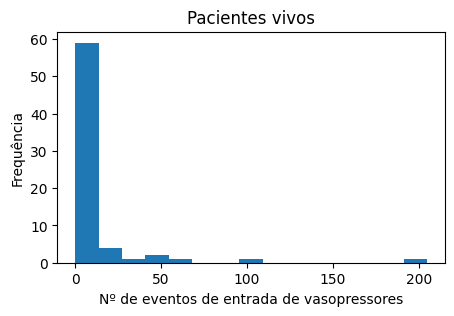

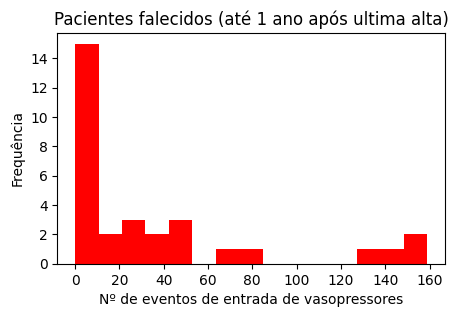

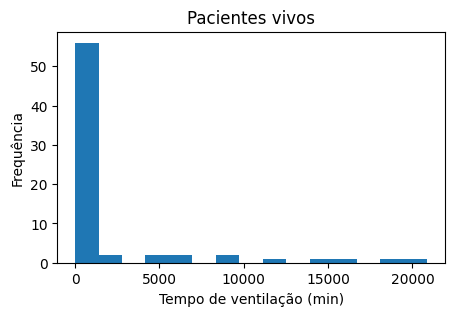

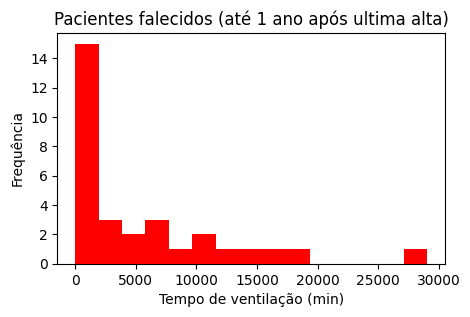

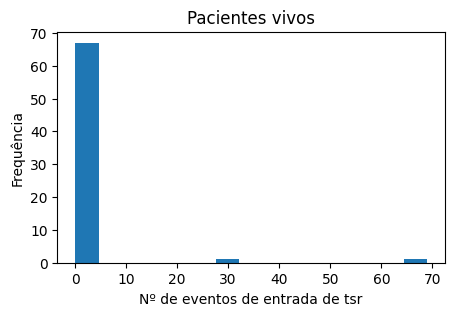

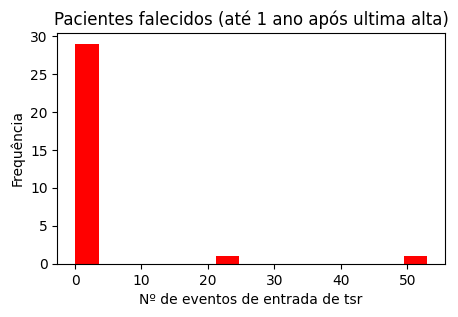

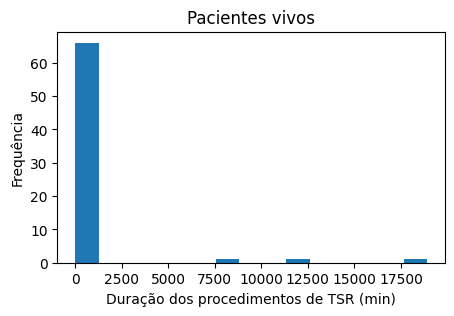

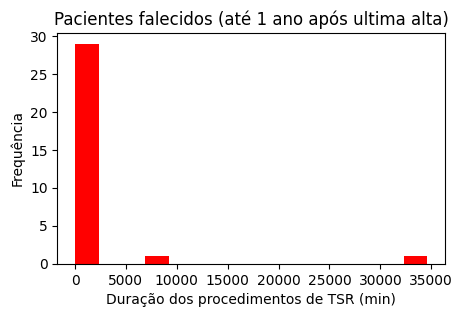

In [279]:

vivos = tabelona[tabelona['dod'].isna()]
mortos = tabelona[~tabelona['dod'].isna()]

# VASOPRESSORES
plt.figure(figsize=[5,3])
plt.title("Pacientes vivos")
plt.ylabel("Frequência")
plt.xlabel("Nº de eventos de entrada de vasopressores")
plt.hist(vivos['vasopressor_input_count'],bins=15)
plt.show()
plt.figure(figsize=[5,3])
plt.title("Pacientes falecidos (até 1 ano após ultima alta)")
plt.ylabel("Frequência")
plt.xlabel("Nº de eventos de entrada de vasopressores")
plt.hist(mortos['vasopressor_input_count'],bins=15,color='red')
plt.show()

# VENTILAÇÃO
plt.figure(figsize=[5,3])
plt.title("Pacientes vivos")
plt.ylabel("Frequência")
plt.xlabel("Tempo de ventilação (min)")
plt.hist(vivos['ventilation_time (min)'],bins=15)
plt.show()
plt.figure(figsize=[5,3])
plt.title("Pacientes falecidos (até 1 ano após ultima alta)")
plt.ylabel("Frequência")
plt.xlabel("Tempo de ventilação (min)")
plt.hist(mortos['ventilation_time (min)'],bins=15,color='red')
plt.show()

# ENTRADA DE TSR
plt.figure(figsize=[5,3])
plt.title("Pacientes vivos")
plt.ylabel("Frequência")
plt.xlabel("Nº de eventos de entrada de tsr")
plt.hist(vivos['tsr_input_count'],bins=15)
plt.show()
plt.figure(figsize=[5,3])
plt.title("Pacientes falecidos (até 1 ano após ultima alta)")
plt.ylabel("Frequência")
plt.xlabel("Nº de eventos de entrada de tsr")
plt.hist(mortos['tsr_input_count'],bins=15,color='red')
plt.show()

# PROCEDIMENTOS DE TSR
plt.figure(figsize=[5,3])
plt.title("Pacientes vivos")
plt.ylabel("Frequência")
plt.xlabel("Duração dos procedimentos de TSR (min)")
plt.hist(vivos['tsr_event_time (min)'],bins=15)
plt.show()
plt.figure(figsize=[5,3])
plt.title("Pacientes falecidos (até 1 ano após ultima alta)")
plt.ylabel("Frequência")
plt.xlabel("Duração dos procedimentos de TSR (min)")
plt.hist(mortos['tsr_event_time (min)'],bins=15,color='red')
plt.show()

#### Pairplot para identificar alguma correlação visual

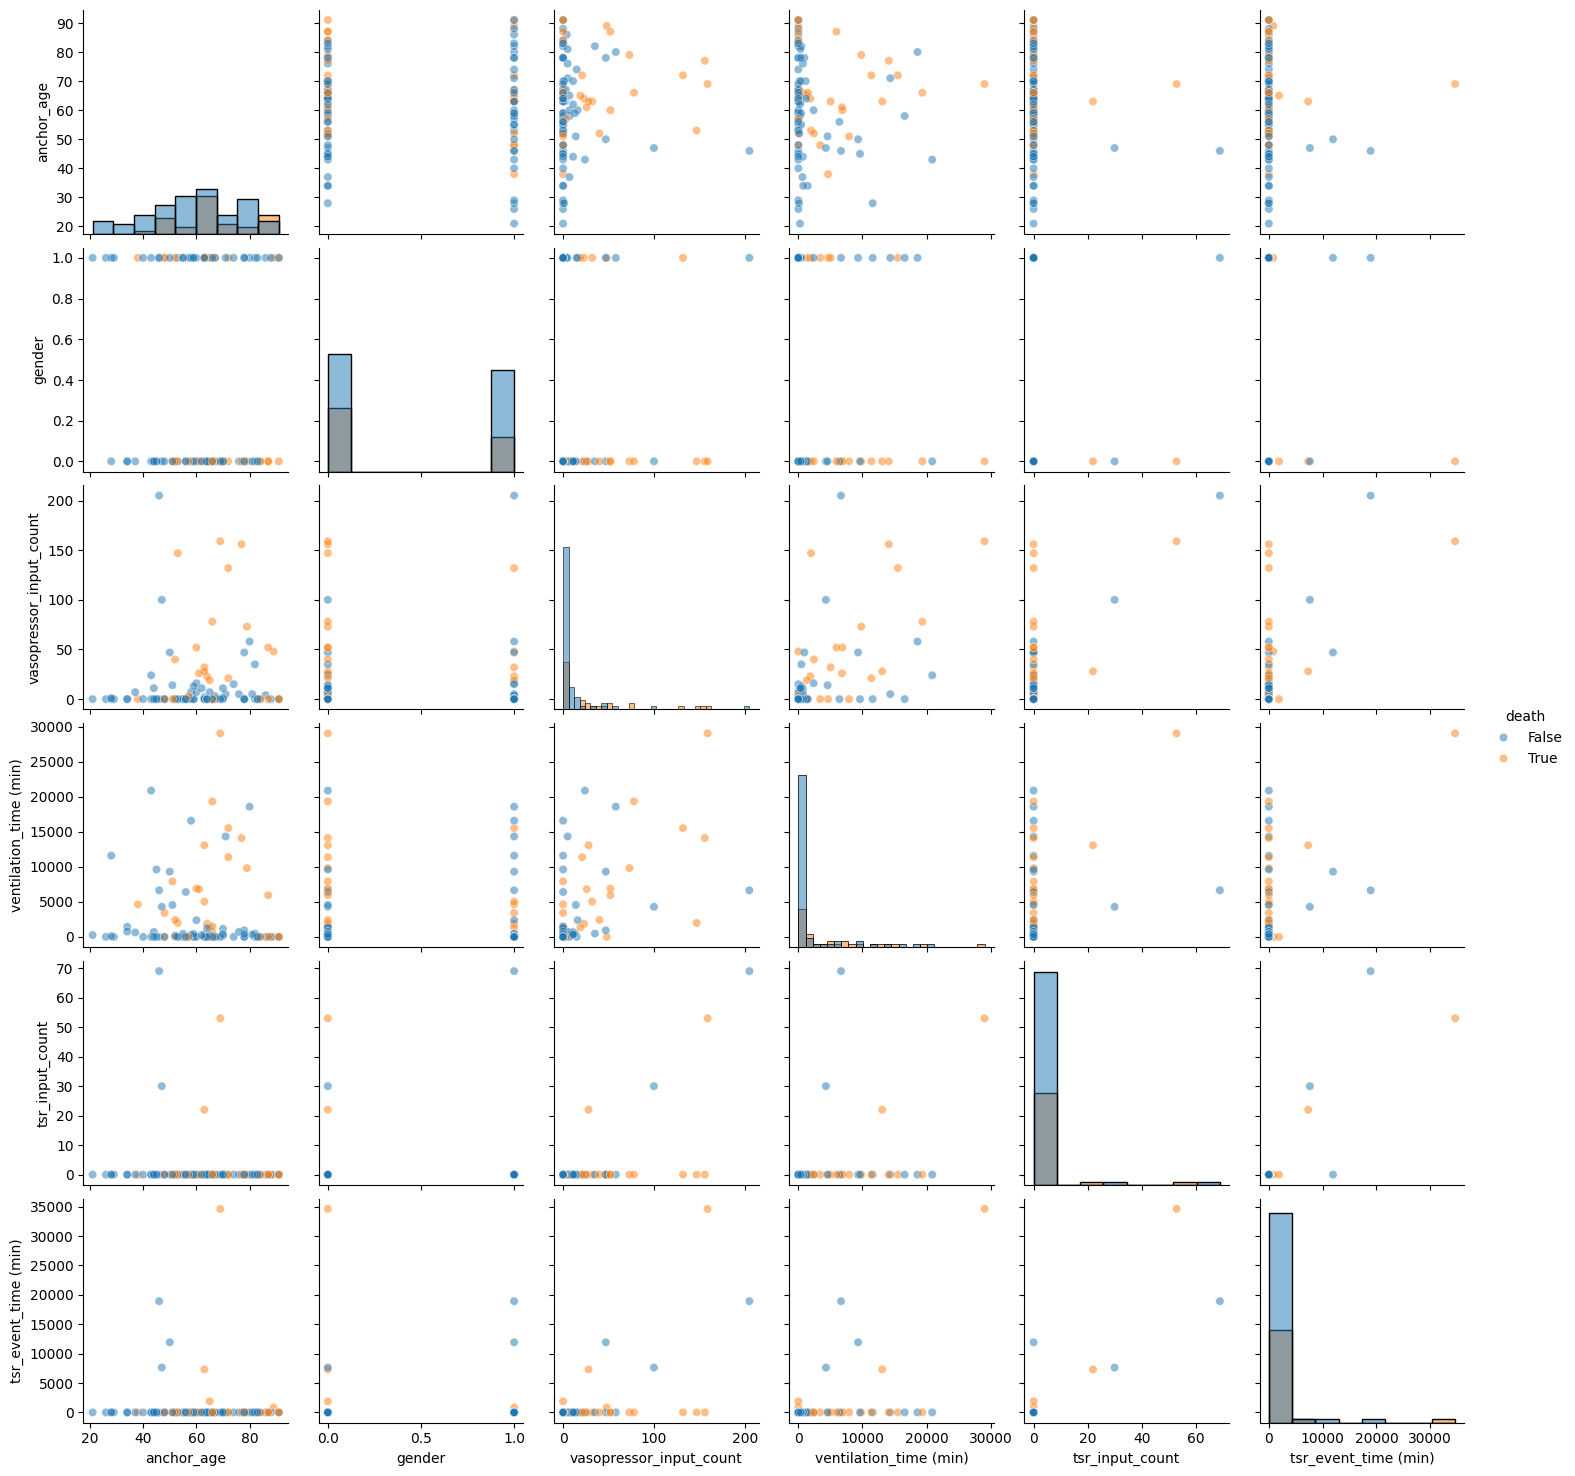

In [301]:
sns.pairplot(tabelona[['anchor_age','gender','vasopressor_input_count','ventilation_time (min)','tsr_input_count','tsr_event_time (min)','death']],hue='death',plot_kws={'alpha': 0.5},diag_kind="hist")

Text(0.5, 1.0, 'Morte x tempo de ventilação x contagem de vasopressores')

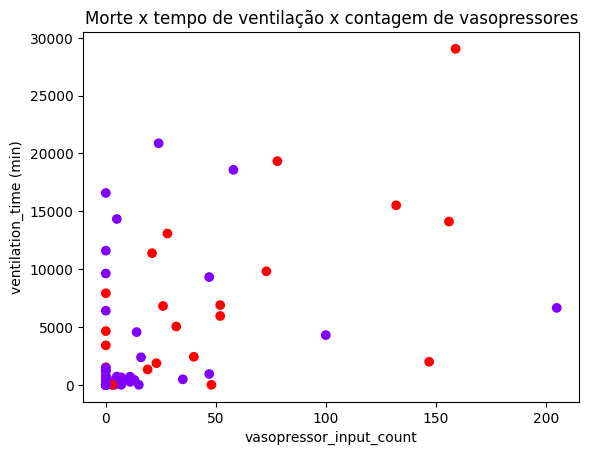

In [308]:
plt.scatter(tabelona['vasopressor_input_count'],tabelona['ventilation_time (min)'],c=tabelona['death'],cmap='rainbow')
plt.xlabel("vasopressor_input_count")
plt.ylabel("ventilation_time (min)")
plt.title("Morte x tempo de ventilação x contagem de vasopressores")